# Education Spending

## Notes 

Focus of this notebook is to compare expenditures by function to a reference group.

Key measures are nominal vs. inflation-adjusted spending, and spending growth.

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [1]:
import os
from os import path, mkdir
import glob
import re
import warnings
from datetime import datetime
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"
    
def dollar_k1(x, pos):
    return f"${int(x/1000):,.1f}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_k1_formatter = ticker.FuncFormatter(dollar_k1)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "",
'Author': 'Joel Danke',
'Description': "DRG E",
'Creation Time': rundate,
'Software': software}

## Read data

In [5]:
# all have the "grouping" vars JSG, % w/Bachelors, etc.
totalstaff = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/totalstaff.parquet')
function_exp = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/expenditures.parquet')
accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability.parquet')


## Filter to "Peer Group"
Dropping Southington - it is just too large!

In [6]:
# peer selection
PEERVAR = "finprojE"
peer_condition = f"{PEERVAR} > 0"

#make directory if needed
try:
    mkdir(f"./charts/peer_districts/{PEERVAR}")
except FileExistsError:
    pass

### Staffing
This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [7]:
# ignore elementary districts
totalstaff['SpecialEd Share Of Ed'] = (totalstaff['SpecialEd'] / (totalstaff['Educational'] + totalstaff['SpecialEd']))
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                       (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')]\
            .query(peer_condition).copy()

peerstaff = peerstaff[~peerstaff['District'].str.startswith('Southington')]
peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

### Expenditures

In [8]:
# filter to remove non-essential schools, functions
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services'])) &
                                (function_exp['High Grade'] == 12)]\
                    .query(peer_condition).copy()

# not sure this is used
peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE Growth'].median().reset_index().rename(columns={'PPE Growth': 'Median PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])

peer_expenditures = peer_expenditures[~peer_expenditures['District'].str.startswith('Southington')]
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

In [9]:
function_exp.groupby('Function').agg({'District': 'nunique', 'Year': 'nunique'})

,District,Year
Function,,
Administration and Support Services,190,5
Central and other support services,199,8
Enterprise operations,199,8
Food services,199,8
Instruction,199,13
Minor school construction,199,8
Operation and maintenance of plant,199,13
Student transportation services,199,13
Support services - general administration,199,13


In [10]:
function_exp.groupby('Function').agg({'Year': 'max'})

,Year
Function,
Administration and Support Services,2016-17
Central and other support services,2024-25
Enterprise operations,2024-25
Food services,2024-25
Instruction,2024-25
Minor school construction,2024-25
Operation and maintenance of plant,2024-25
Student transportation services,2024-25
Support services - general administration,2024-25


### Accountability

**No Covid Years**  

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

In [11]:
# remove nonessential schools
peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                     (accountability['High Grade'] == 12)]\
                     .query(peer_condition).copy()

peer_accountability = peer_accountability[~peer_accountability['District'].str.startswith('Southington')]
peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')

## Combine accountability, expenditures, staffing

Select columns to avoid duplicates.

In [12]:
# Avoid duplicating clustering variables when getting staff data
peerdrop = [x for x in peerstaff.columns if ((x in peer_expenditures.columns) & (x not in ['Year', 'District']))]

# For accountability index select only necessary variables
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
           'Physical Fitness', 'Arts Access', 'AccountabilityIndex']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

In [13]:
# add "total" expenditures, accountability index
peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total']\
                .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])
peer_combined['Expenditures Per Student'] = peer_combined['Expenditures'] / peer_combined['Enrollment']

# same, but for "instructional" expenditures
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction']\
                   .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                   .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])

peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

In [14]:
# help w/plotting styles
peerstaff[PEERVAR] = peerstaff[PEERVAR].where(~peerstaff['District'].str.startswith('Region'), 3)
peer_expenditures[PEERVAR] = peer_expenditures[PEERVAR].where(~peer_expenditures['District'].str.startswith('Region'), 3)
peer_accountability[PEERVAR] = peer_accountability[PEERVAR].where(~peer_accountability['District'].str.startswith('Region'), 3)
peer_combined[PEERVAR] = peer_combined[PEERVAR].where(~peer_combined['District'].str.startswith('Region'), 3)
peer_instruction[PEERVAR] = peer_instruction[PEERVAR].where(~peer_instruction['District'].str.startswith('Region'), 3)

### Peer Overview

In [15]:
peer_combined.query('Year == "2024-25"')[['Year', 'District', 'Enrollment', 'Expenditures', 'AccountabilityIndex', 'Payroll Per Student', 'Expenditures Per Student']]\
    .sort_values('Expenditures Per Student')\
    .style.format({"AccountabilityIndex": "{:,.1f}"} |
                  { x: "${:,.0f}" for x in ["Payroll Per Student", "Expenditures Per Student", "Expenditures"]} |
                  {'Enrollment': "{:,.0f}"} )\
    .hide(axis="index")

Year,District,Enrollment,Expenditures,AccountabilityIndex,Payroll Per Student,Expenditures Per Student
2024-25,Wolcott School District,"2,100","$43,335,531",78.3,"$15,370","$20,636"
2024-25,Granby School District,"1,709","$39,033,285",82.8,"$17,085","$22,840"
2024-25,East Hampton School District,"1,676","$40,740,556",77.2,"$19,827","$24,308"
2024-25,Thomaston School District,777,"$19,656,075",77.7,"$17,404","$25,297"
2024-25,East Windsor School District,"1,035","$31,272,689",71.6,"$23,920","$30,215"


In [16]:
# Largest YoY growth
peer_expenditures[peer_expenditures['Function'] == 'Instruction'].groupby('District')['Real PPE Growth'].max().sort_values()

District
Thomaston School District       1.038985
East Windsor School District    1.084057
Wolcott School District         1.084518
Granby School District          1.147319
East Hampton School District    1.167050
Name: Real PPE Growth, dtype: float64

### Year vs 2ago changes
Attempt to comparing instructional and accountability growth. No COVID years is problematic

In [17]:
# calculate % change from prior year
changecols = ['Pupils', 'PPE', 'Instruction $', 'Instruction $ Per Student',
              'Real Instruction $', 'Real PPE', 'Real Instruction $ Per Student',
              'Teachers', 'Educational', 'Student: Teachers Ratio', 'AccountabilityIndex']

# % change vs two years ago
changes = peer_instruction.groupby('District')[changecols].diff(2)/peer_instruction.groupby('District')[changecols].shift(2)

changes = changes.join(peer_instruction[['District', 'Year', 'Town', 'Type', 'Granby']].rename(columns={'Pupils': 'Students'}), how='inner')

changes.head(10).tail(5)

,Pupils,PPE,Instruction $,Instruction $ Per Student,Real Instruction $,Real PPE,Real Instruction $ Per Student,Teachers,Educational,Student: Teachers Ratio,AccountabilityIndex,District,Year,Town,Type,Granby
5,0.045230,0.044993,0.092241,0.044993,0.055787,0.010116,0.010116,0.028571,0.029762,-0.040104,0.045056,East Hampton School District,2017-18,East Hampton,Town,Other
6,0.045916,0.041106,0.088896,0.041106,0.050409,0.004307,0.004307,-0.055646,-0.046310,0.054974,0.085840,East Hampton School District,2018-19,East Hampton,Town,Other
7,-0.036511,0.033998,-0.003766,0.033998,-0.037060,-0.000558,-0.000558,-0.073529,-0.057803,0.063772,NaN,East Hampton School District,2019-20,East Hampton,Town,Other
8,-0.040327,0.097035,0.052770,0.097035,0.022909,0.065919,0.065919,-0.024263,-0.016692,0.000191,NaN,East Hampton School District,2020-21,East Hampton,Town,Other
9,-0.036842,0.137834,0.095961,0.137834,0.018944,0.057875,0.057875,0.012346,0.026840,-0.042226,NaN,East Hampton School District,2021-22,East Hampton,Town,Other


## Reshape Data
Easier way to work with hues

In [18]:
# reshape accountability wide-to-long for seaborn
peer_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=values,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

high_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=high_need,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

## Color Scheme

In [19]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in peer_combined['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .45),
             2: 'black',
             1: (0.529, 0.808, 0.922, .45)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

## Inflation Adjusted Spending Growth
### Shrinking Enrollment Drives Costs

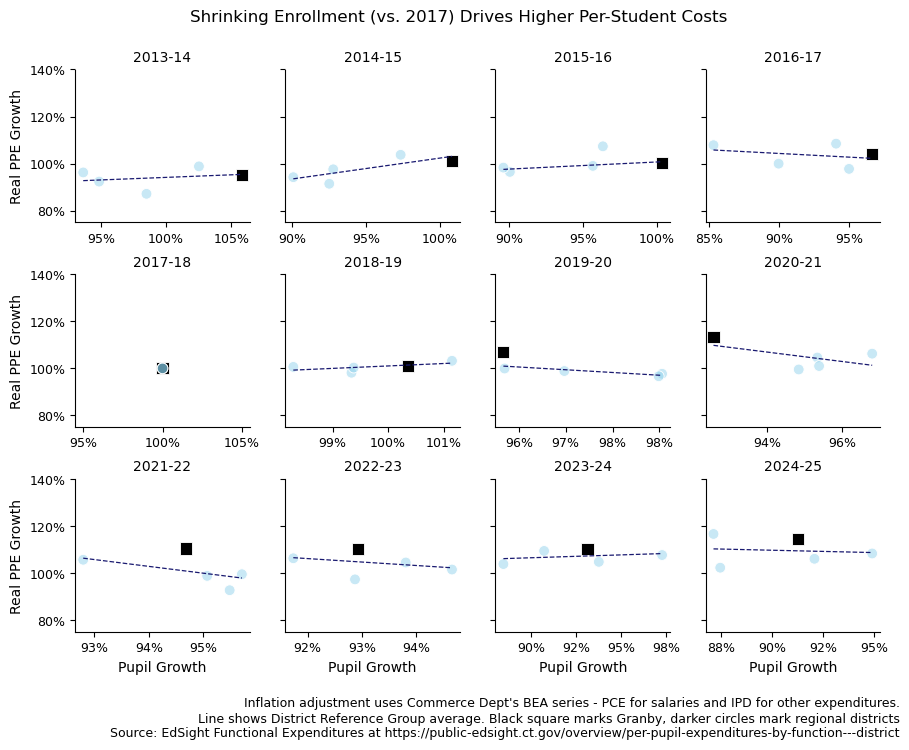

In [20]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Function'] == 'Instruction') &
                     (peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])],
               x='Pupil Growth', y='Real PPE Growth', 
               col='Year', col_wrap=4, facet_kws={'sharex':False},
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 76],
               hue = PEERVAR)

g.fig.suptitle("Shrinking Enrollment (vs. 2017) Drives Higher Per-Student Costs")

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupil Growth', y='Real PPE Growth',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(.75,1.4))

for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=9)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Line shows District Reference Group average. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Inflation adjustment uses Commerce Dept's BEA series - PCE for salaries and IPD for other expenditures.\n"
line3 = "Source: EdSight Functional Expenditures at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_v_student_growth.png", dpi=200, metadata=png_metadata)   
    
plt.show()

### By Functional Expenditure

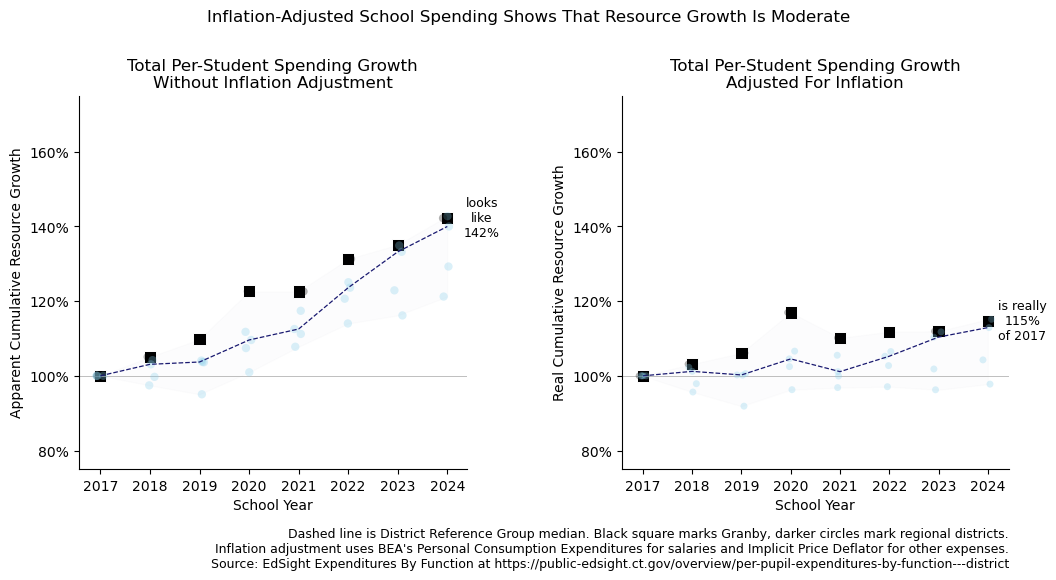

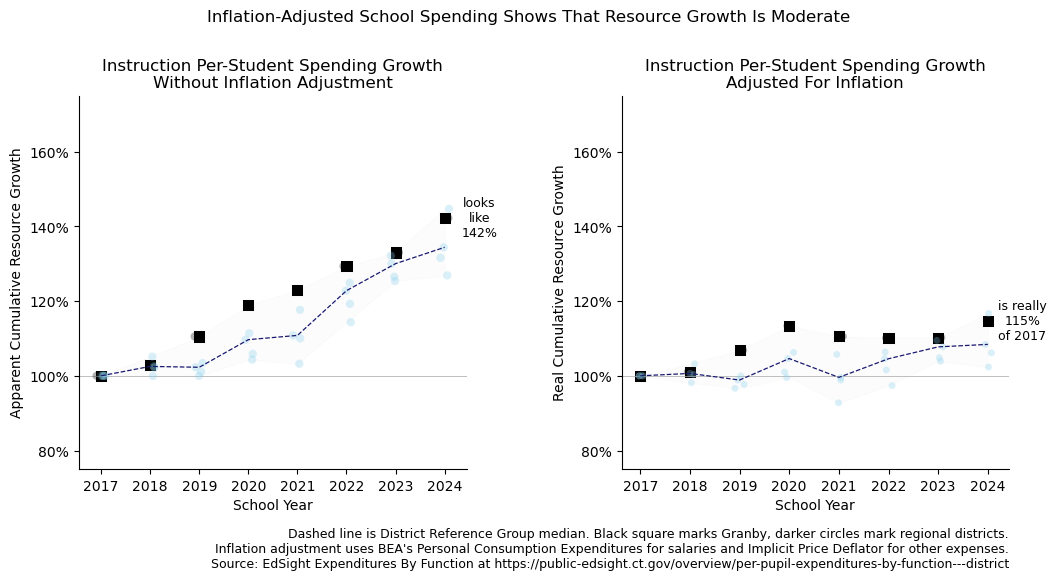

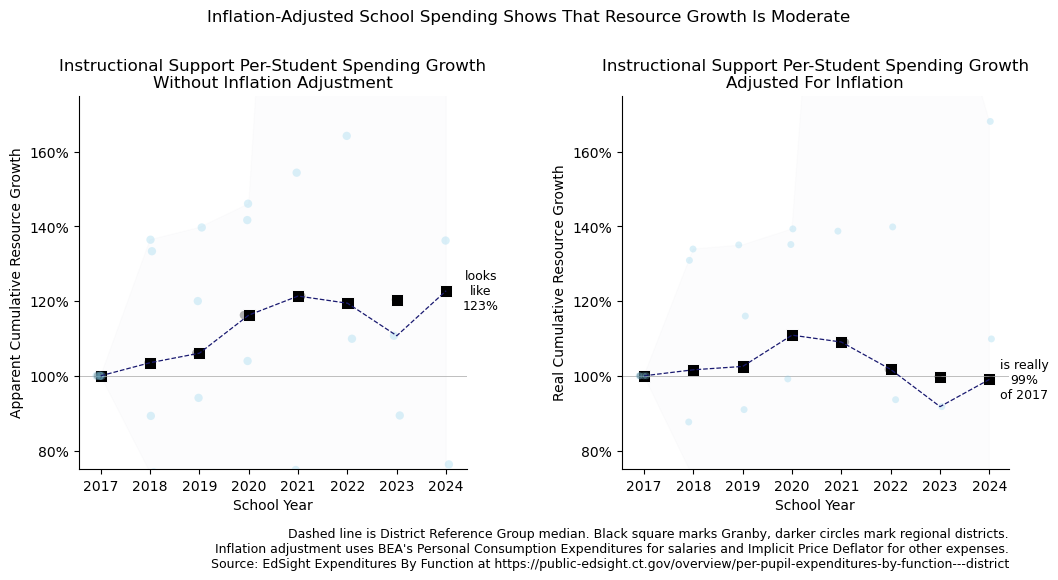

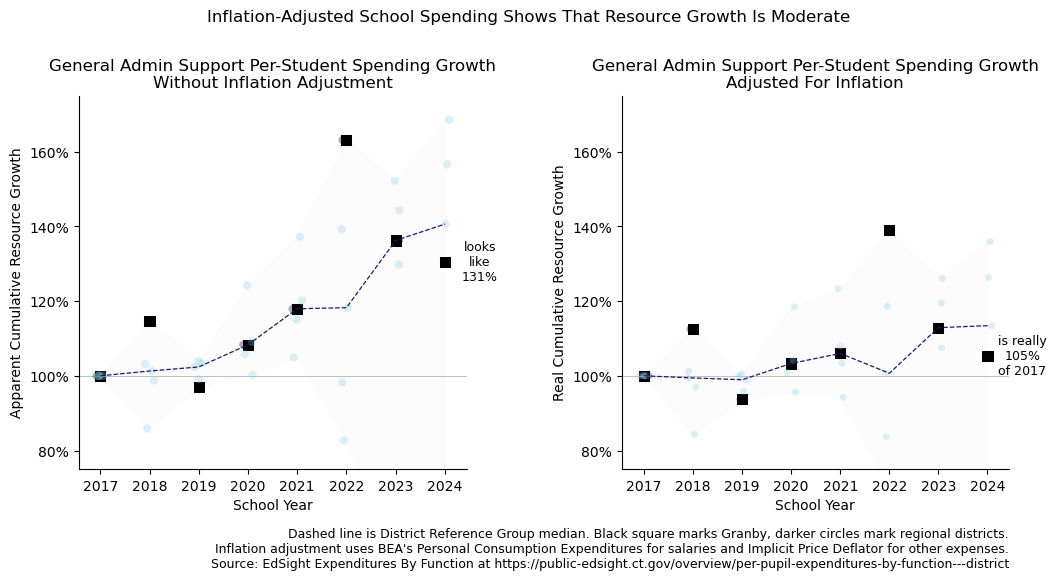

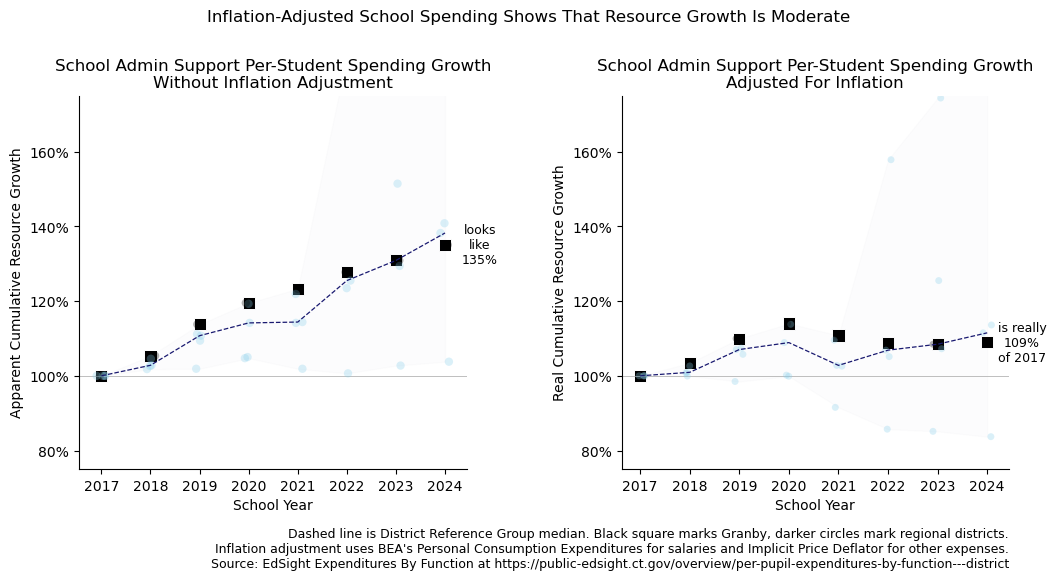

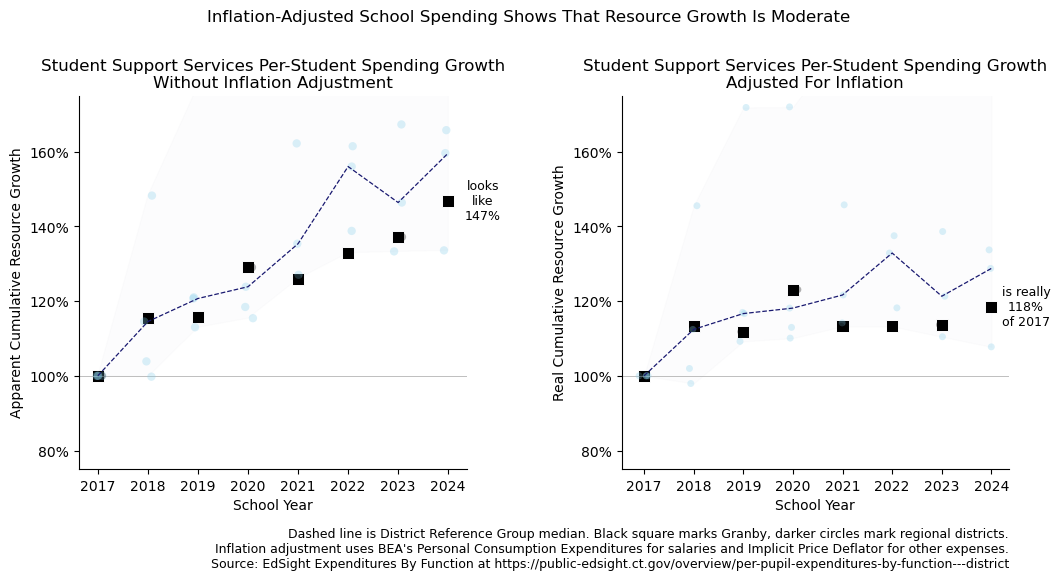

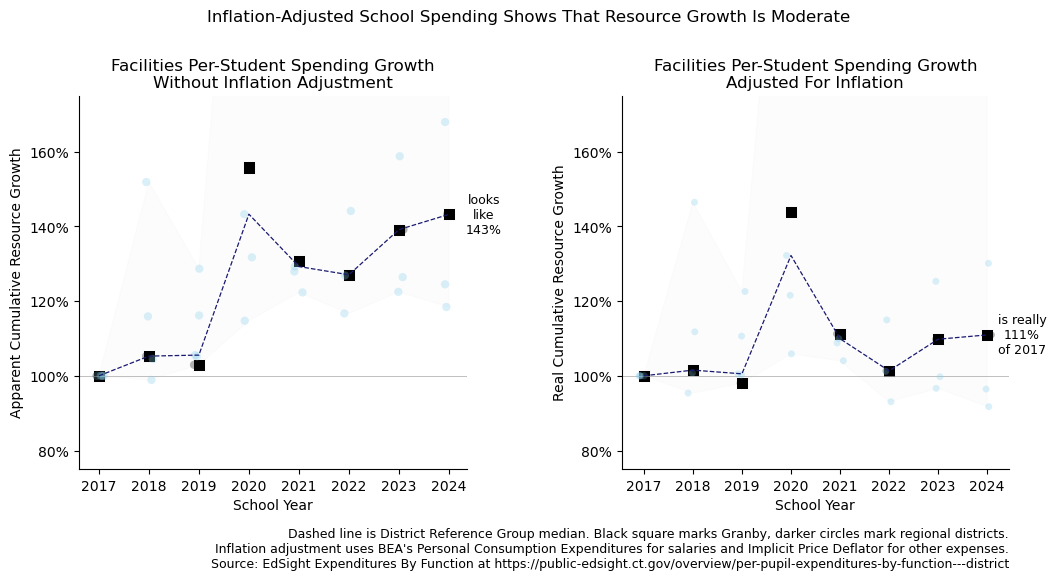

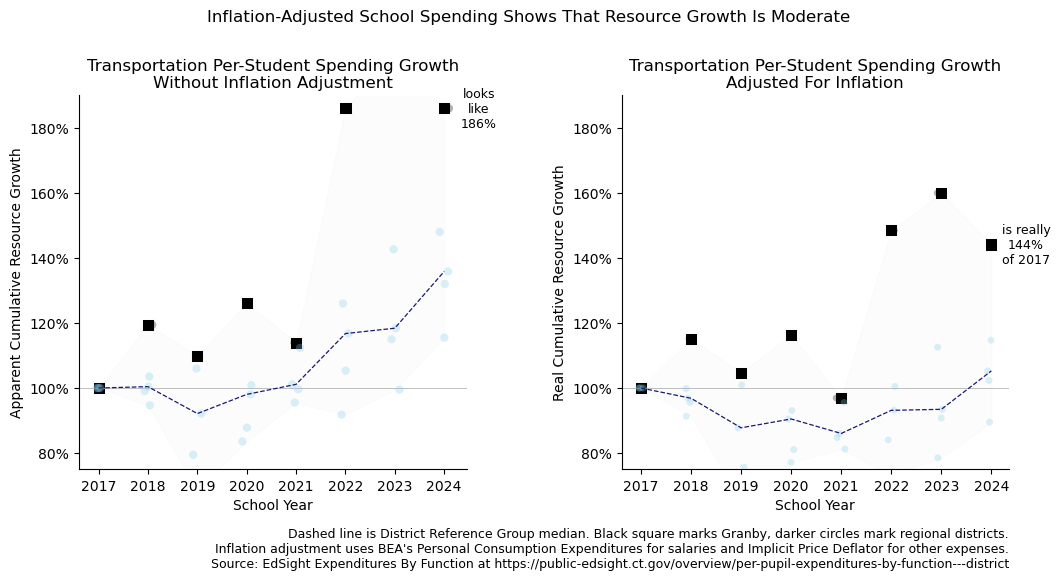

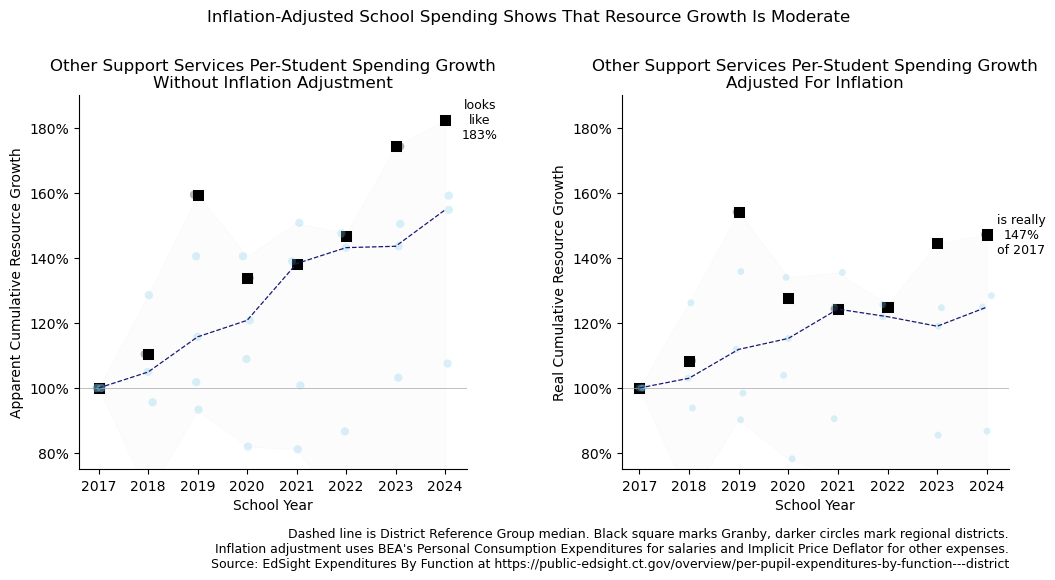

In [21]:
_functionlist = {'Total': 'Total',
                 'Instruction': 'Instruction',
                 'Support services - instruction': 'Instructional Support',
                 'Support services - general administration': 'General Admin Support',
                 'Support services - school based administration': 'School Admin Support',
                 'Support services - students': 'Student Support Services',
                 'Operation and maintenance of plant': 'Facilities',
                 'Student transportation services': 'Transportation',
                 'Central and other support services': 'Other Support Services',
                 }

for k, item in _functionlist.items():
    _df = peer_expenditures[(peer_expenditures['Function'] == k)
                                               & (peer_expenditures['School Year'] > '2016')]
    
    with warnings.catch_warnings(action="ignore"):
    
        fig, axs = plt.subplots(1, 2, figsize=(12,5.75), gridspec_kw={'wspace':.4})
        
        fig.suptitle("Inflation-Adjusted School Spending Shows That Resource Growth Is Moderate")
    
        # first plot
        g = axs[0]
        g.set_title(f"{item} Per-Student Spending Growth\nWithout Inflation Adjustment")
        g = sns.stripplot(data=_df,
                          x='School Year', y='PPE Growth',  ax=axs[0],
                          palette=peer_cols, legend=None, size=6, alpha=.3,
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby PPEG', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=g,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='PPE Growth', estimator='median', color='midnightblue', ax=g,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        g.set_ylabel("Apparent Cumulative Resource Growth")
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby PPEG'].item()
        
        g.annotate(f"looks\nlike\n{_infl:.0%}", (_df['School Year'].max(), min(1.9, _infl)), 
                 xytext=(25,0), textcoords='offset points', va='center', ha='center', fontsize=9)
    
        # second plot
        h = axs[1]
        h.set_title(f"{item} Per-Student Spending Growth\nAdjusted For Inflation")
        h = sns.stripplot(data=_df,
                          x='School Year', y='Real PPE Growth', alpha=.3,
                          palette=peer_cols, legend=None, ax=axs[1], 
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby Real PPEG', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=h,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='Real PPE Growth', estimator='median', color='midnightblue', ax=h,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        h.set_ylabel("Real Cumulative Resource Growth")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby Real PPEG'].item()
        h.annotate(f"is really\n{_infl:.0%}\nof {_df['School Year'].min()}", (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', va='center', ha='center', fontsize=9)
    
        for ax in axs:
            ax.set(ylim=(0.75,1.75))
            ax.axhline(y=1, c='darkgray', ls='-', lw=.7, alpha=.75)
            ax.yaxis.set_major_formatter(perci_formatter)
            
            if ax.get_title().startswith('Transp'):
                ax.set_ylim(top=1.9)
        
            if ax.get_title().startswith('Other'):
                ax.set_ylim(top=1.9)

       
        sns.despine()
    
        plt.tight_layout()
        plt.subplots_adjust(top=.83, bottom=0.18)
        line1 = " Dashed line is District Reference Group median. Black square marks Granby, darker circles mark regional districts.\n"
        line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
        line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
        fig.text(.9, .01, line1 + line2 + line3, ha='right', fontsize=9)
    
        
        plt.savefig(f"./charts/peer_districts/{PEERVAR}/apparent_v_real_{item.split()[0].lower()}_growth.png", dpi=200, metadata=png_metadata)
    
    
        plt.show()

### One-Pagers
#### Nominal

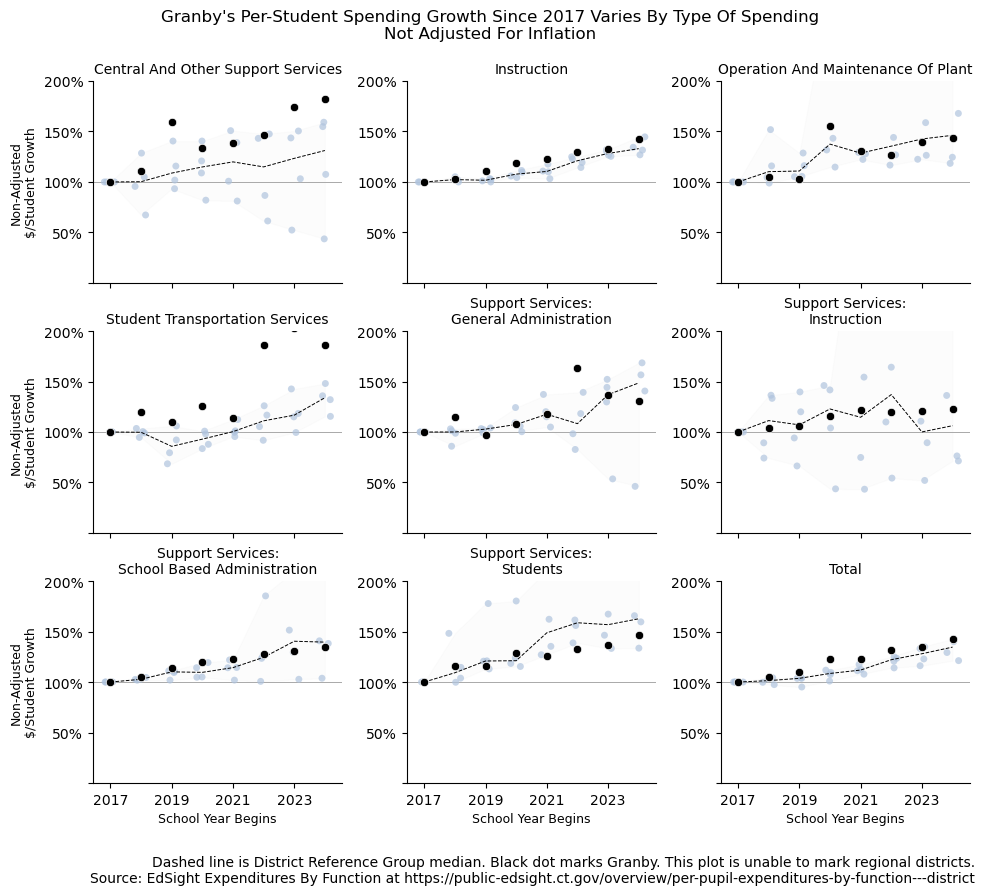

In [22]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Administration'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'PPE Growth', 'Granby PPEG']].copy()
_df['PPE Growth'] = _df['PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=3, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Non-Adjusted\n$/Student Growth", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)
g.set(ylim=(0,2))
doit=0

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)

plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle("Granby's Per-Student Spending Growth Since 2017 Varies By Type Of Spending\nNot Adjusted For Inflation")

line1 = "Dashed line is District Reference Group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_nominal.png", dpi=200, metadata=png_metadata)

plt.show()

#### Inflation-Adjusted

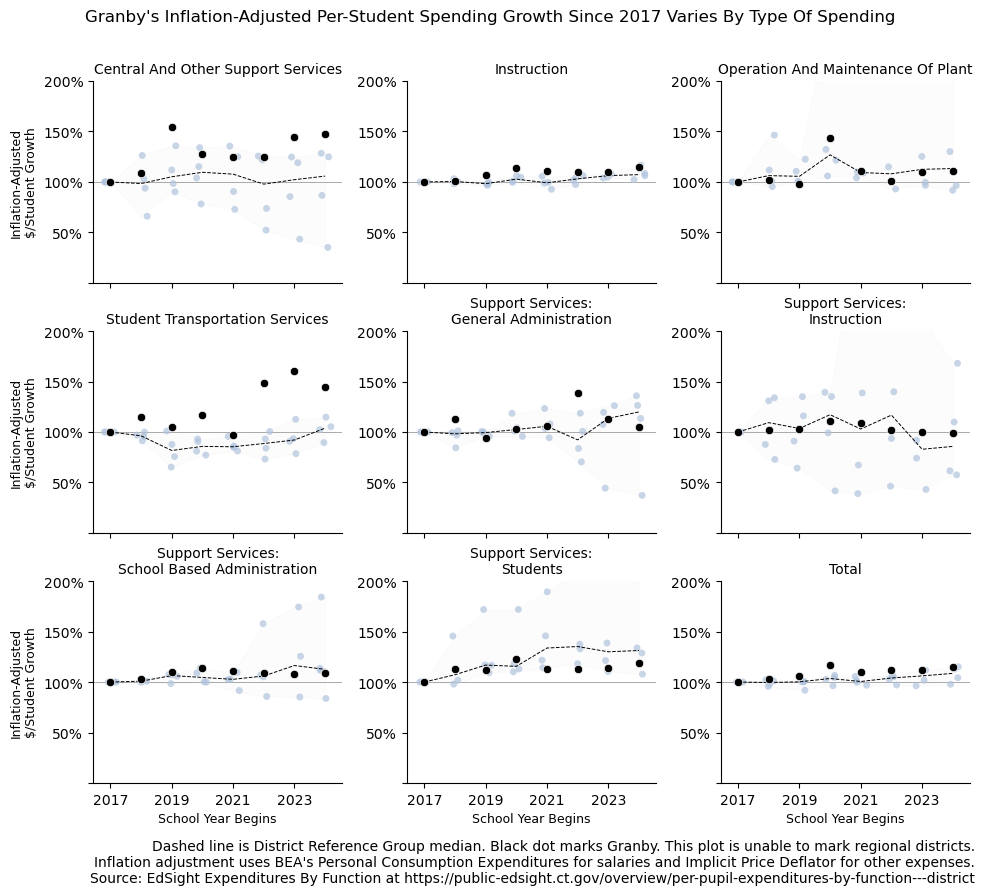

In [23]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Administration'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE Growth', 'Granby Real PPEG']].copy()
_df['Real PPE Growth'] = _df['Real PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=3, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Inflation-Adjusted\n$/Student Growth", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)
g.set(ylim=(0,2))
doit=0

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)
    
plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle("Granby's Inflation-Adjusted Per-Student Spending Growth Since 2017 Varies By Type Of Spending")

line1 = "Dashed line is District Reference Group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_real.png", dpi=200, metadata=png_metadata)

plt.show()

#### Historical

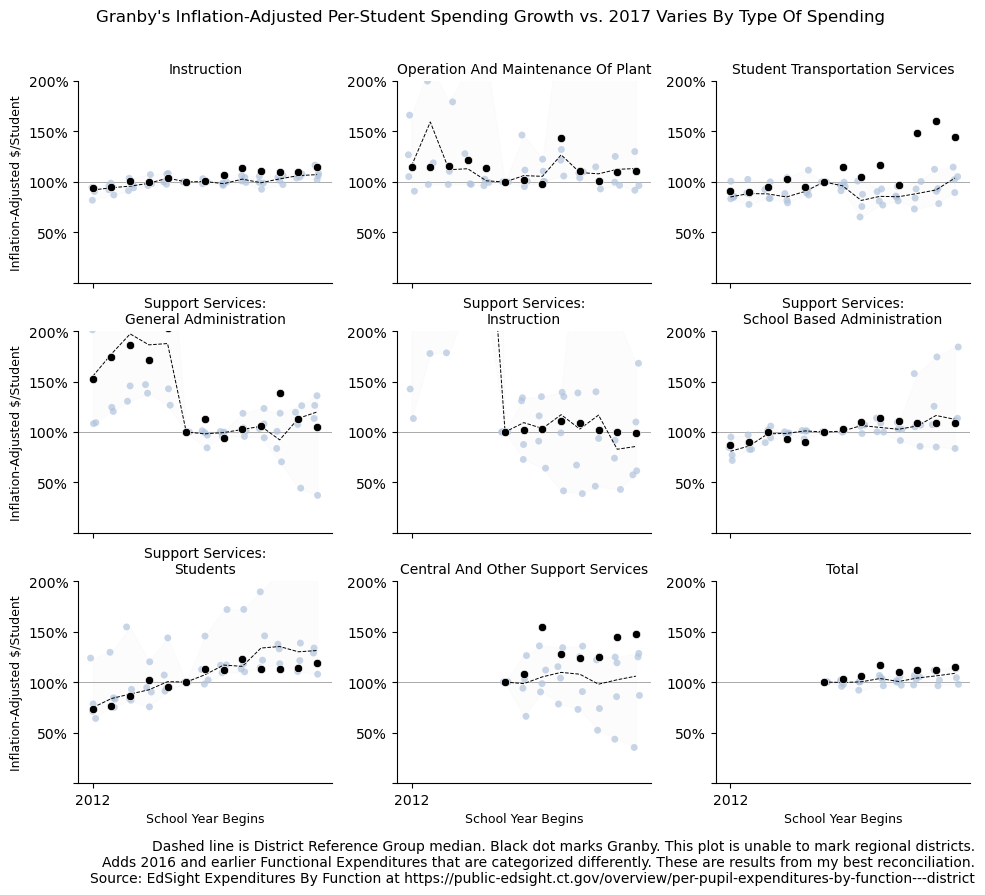

In [24]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Administration'))
                  ]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE Growth', 'Granby Real PPEG']].copy()
_df['Real PPE Growth'] = _df['Real PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=3, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")

g.set_ylabels("Inflation-Adjusted $/Student", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)

g.set(ylim=(0,2))


for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    
    xt = ax.get_xticks()
    doit=0
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)

plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle("Granby's Inflation-Adjusted Per-Student Spending Growth vs. 2017 Varies By Type Of Spending")

line1 = "Dashed line is District Reference Group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Adds 2016 and earlier Functional Expenditures that are categorized differently. These are results from my best reconciliation.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_historical.png", dpi=200, metadata=png_metadata)

plt.show()

## Per Student Spending
### By Functional Expenditure

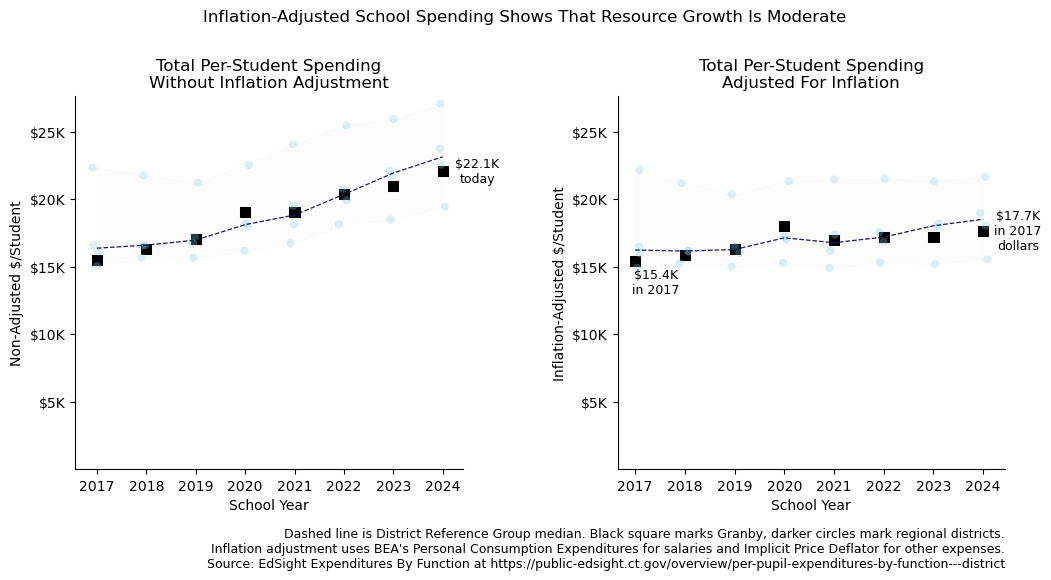

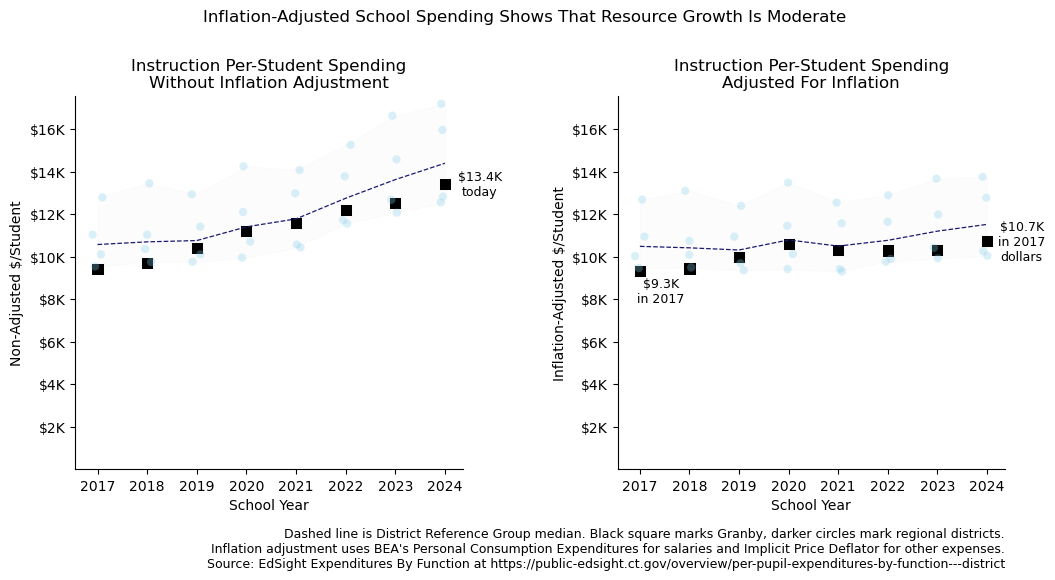

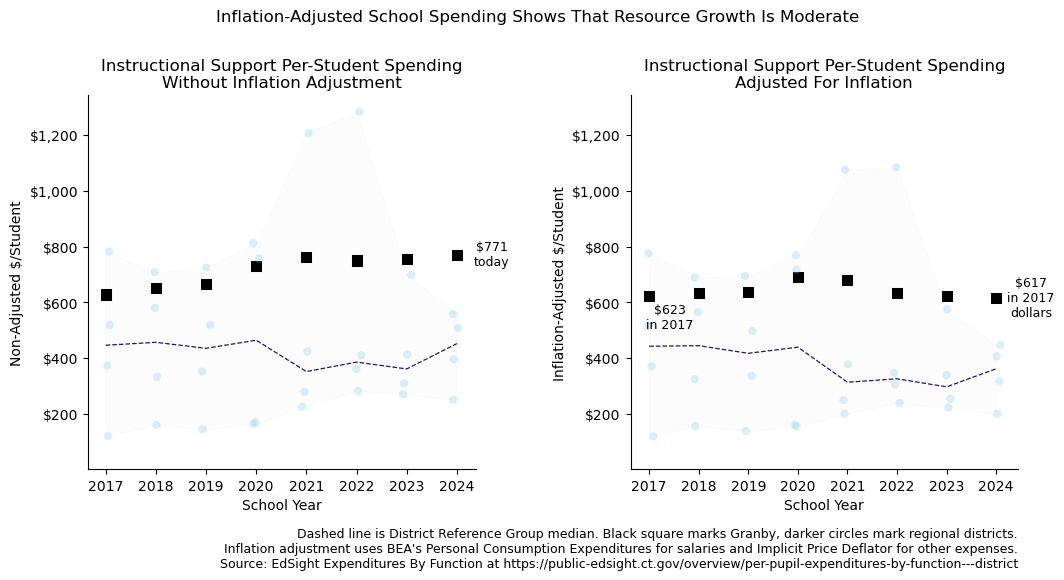

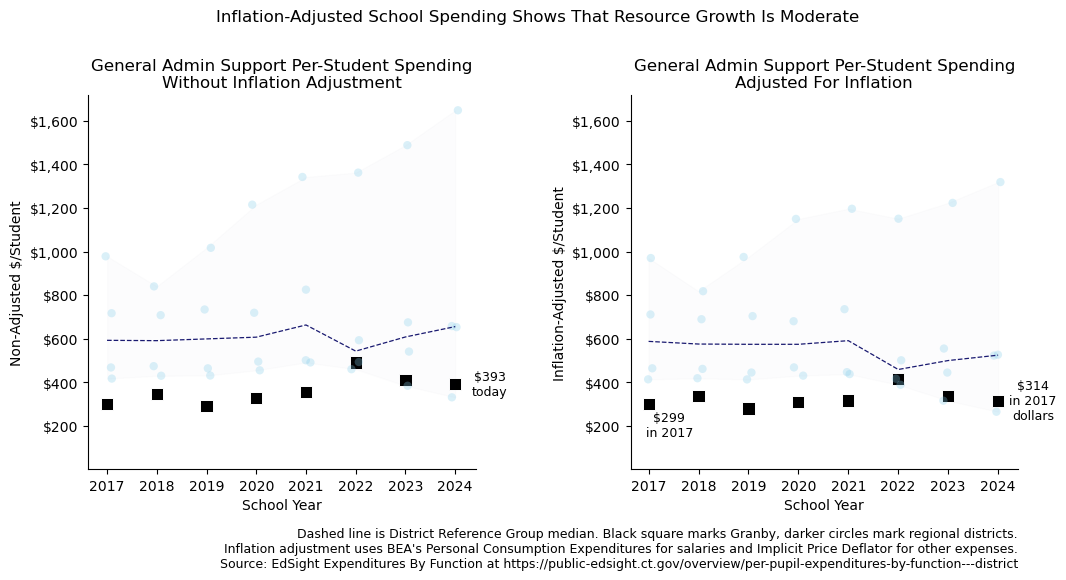

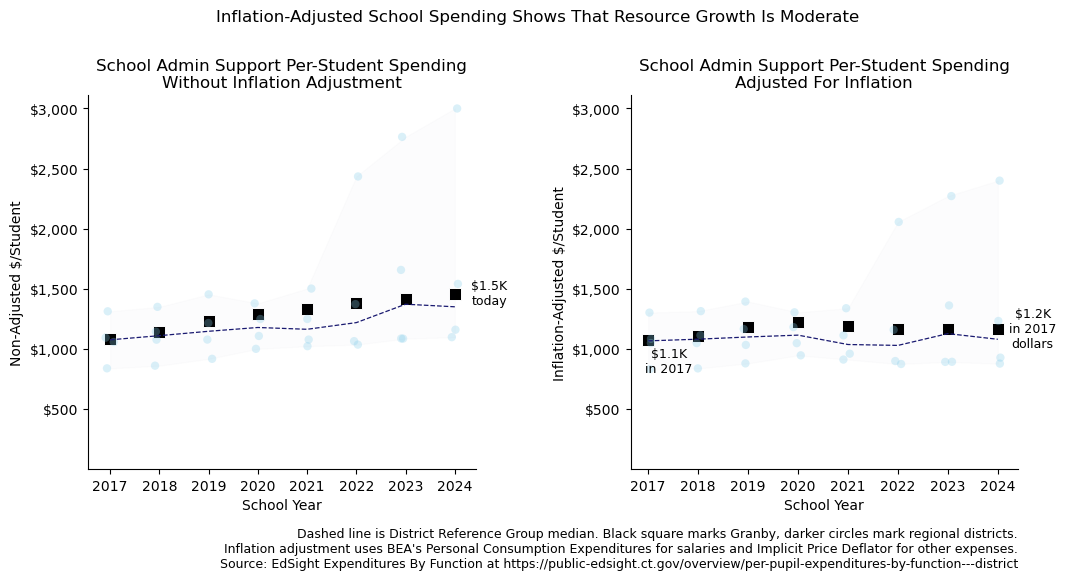

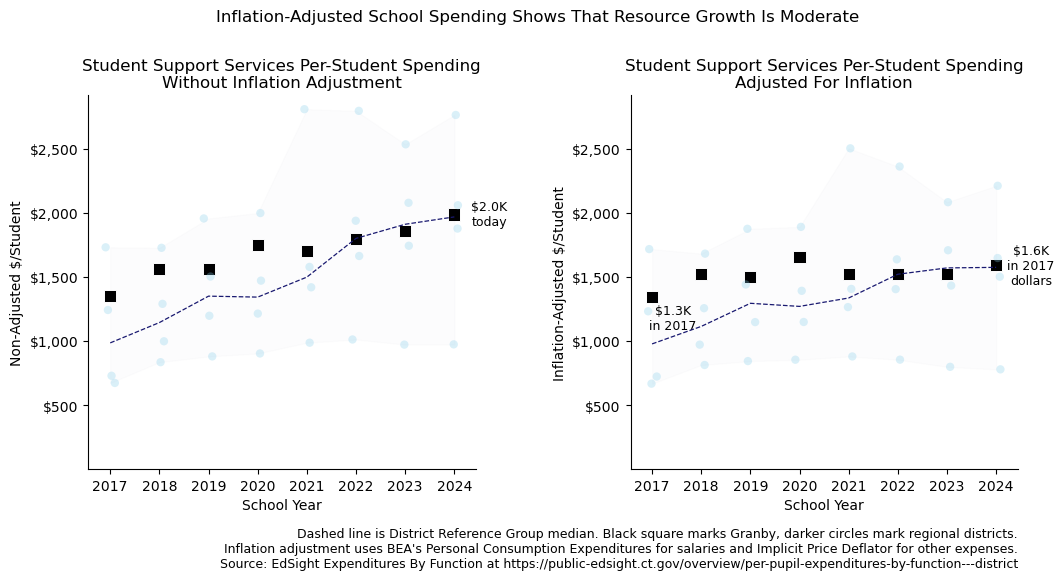

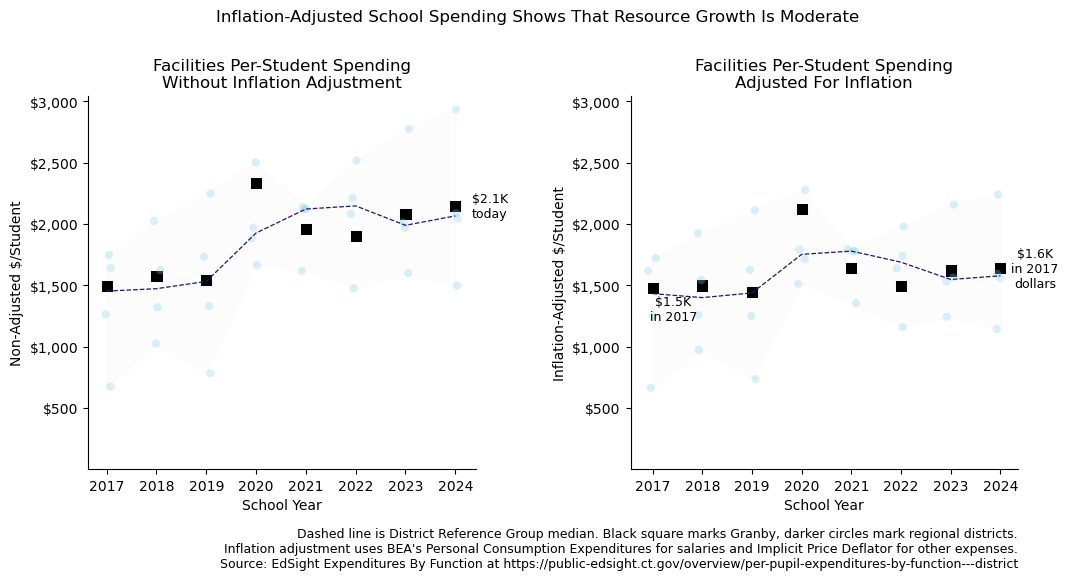

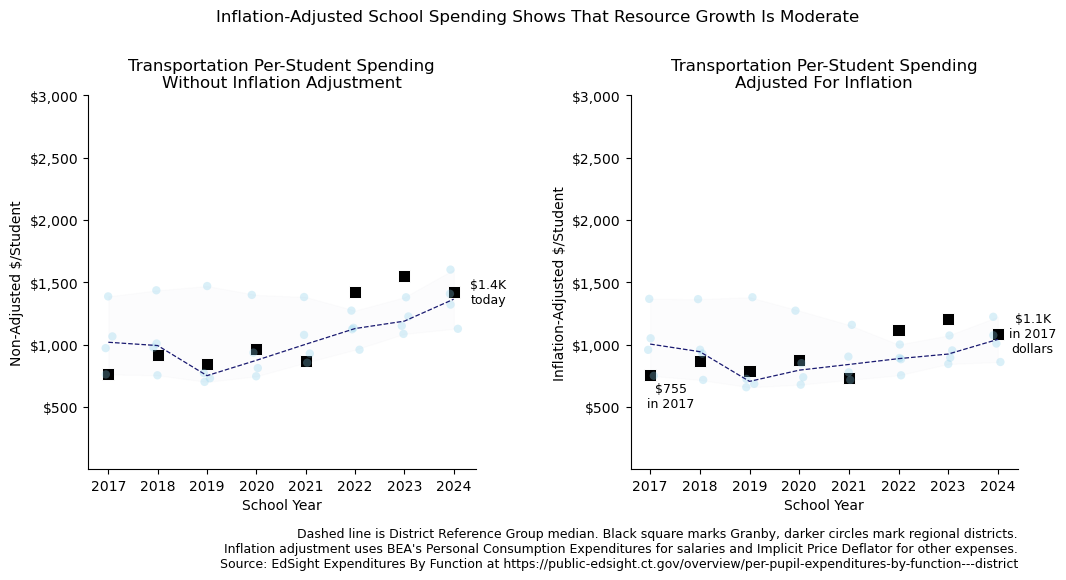

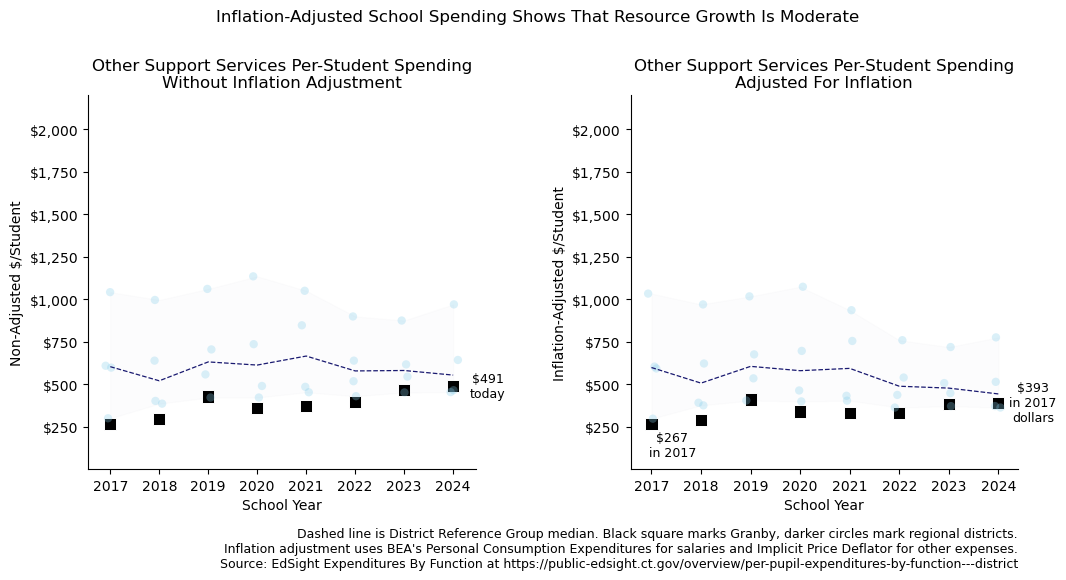

In [25]:

for k, item in _functionlist.items():

    _df = data=peer_expenditures[(peer_expenditures['Function'].str.startswith(k))
                      & (peer_expenditures['School Year'] > '2016')]\
                [['School Year', 'District', 'Town', 'Granby', f"{PEERVAR}", 'Function', 'PPE', 'Real PPE']].copy()

    # need a granby series
    _df['Granby PPE'] = _df['PPE'].where(_df['Town'] == 'Granby', None)
    _df['PPE'] = _df['PPE'].where(_df['Town'] != 'Granby', np.nan)
    _df['Granby Real PPE'] = _df['Real PPE'].where(_df['Town'] == 'Granby', None)
    _df['Real PPE'] = _df['Real PPE'].where(_df['Town'] != 'Granby', np.nan)

    
    with warnings.catch_warnings(action="ignore"):
    
        fig, axs = plt.subplots(1, 2, figsize=(12,5.75), gridspec_kw={'wspace':.4})
        
        fig.suptitle("Inflation-Adjusted School Spending Shows That Resource Growth Is Moderate")
    
        # first plot
        g = axs[0]
        g.set_title(f"{item} Per-Student Spending\nWithout Inflation Adjustment")
        g = sns.stripplot(data=_df,
                          x='School Year', y='PPE', alpha=.3,
                          ax=axs[0], size=6,
                          palette=peer_cols, legend=None,
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby PPE', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=g,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='PPE', estimator='median', color='midnightblue', ax=g,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        g.set_ylabel("Non-Adjusted $/Student")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby PPE'].item()
        if _infl > 1000 :
            annt = f"${_infl / 1000:.1f}K\ntoday"
        else:
            annt = f"${_infl:,.0f}\ntoday"
            
        g.annotate(annt, (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', ha='center', va='center', fontsize=9)
    
        # second plot
        h = axs[1]
        h.set_title(f"{item} Per-Student Spending\nAdjusted For Inflation")
        h = sns.stripplot(data=_df,
                          x='School Year', y='Real PPE',
                          alpha=.3, size=6,
                          palette=peer_cols, legend=None, ax=axs[1],
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby Real PPE', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=h,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='Real PPE', estimator='median', color='midnightblue', ax=h,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        h.set_ylabel("Inflation-Adjusted $/Student")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby Real PPE'].item()
        
        if _infl > 1000 :
            annt = f"${_infl / 1000:.1f}K\nin 2017\ndollars"
        else:
            annt = f"${_infl:,.0f}\nin 2017\ndollars"
        h.annotate(annt, (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', ha='center', va='center', fontsize=9)
        
        _strt = _df[(_df['School Year'] == _df['School Year'].min()) & (_df.Town == 'Granby')]['Granby Real PPE'].item()
        
        if _strt > 1000 :
            annt = f"${_strt / 1000:.1f}K\nin 2017"
        else:
            annt = f"${_strt:,.0f}\nin 2017"
        h.annotate(annt, (_df['School Year'].min(), _strt), 
                 xytext=(15,-5), textcoords='offset points', ha='center', va='top', fontsize=9)        


        for ax in axs:
            ax.yaxis.set_major_formatter(dollar_k_formatter)
            ax.set_ylim(bottom=1)
            
            if ax.get_title().startswith('Transp'):
                ax.set_ylim(top=3000)
        
            if ax.get_title().startswith('Other'):
                ax.set_ylim(top=2200)

        # same y-scale
        b, t = axs[0].get_ylim()
        axs[1].set_ylim(b,t)

        if t <= 5000:
            axs[0].yaxis.set_major_formatter(dollar_k1_formatter)
            axs[1].yaxis.set_major_formatter(dollar_k1_formatter)
        if t <= 4100:
            axs[0].yaxis.set_major_formatter(dollari_formatter)
            axs[1].yaxis.set_major_formatter(dollari_formatter)
        
        sns.despine()
    
        plt.tight_layout()
        plt.subplots_adjust(top=.83, bottom=0.18)
        line1 = " Dashed line is District Reference Group median. Black square marks Granby, darker circles mark regional districts.\n"
        line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
        line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
        fig.text(.9, .01, line1 + line2 + line3, ha='right', fontsize=9)
    
        
        plt.savefig(f"./charts/peer_districts/{PEERVAR}/apparent_v_real_{item.split()[0].lower()}_ppe.png", dpi=200, metadata=png_metadata)
    
    
        plt.show()

### One-Pagers
#### Inflation-Adjusted

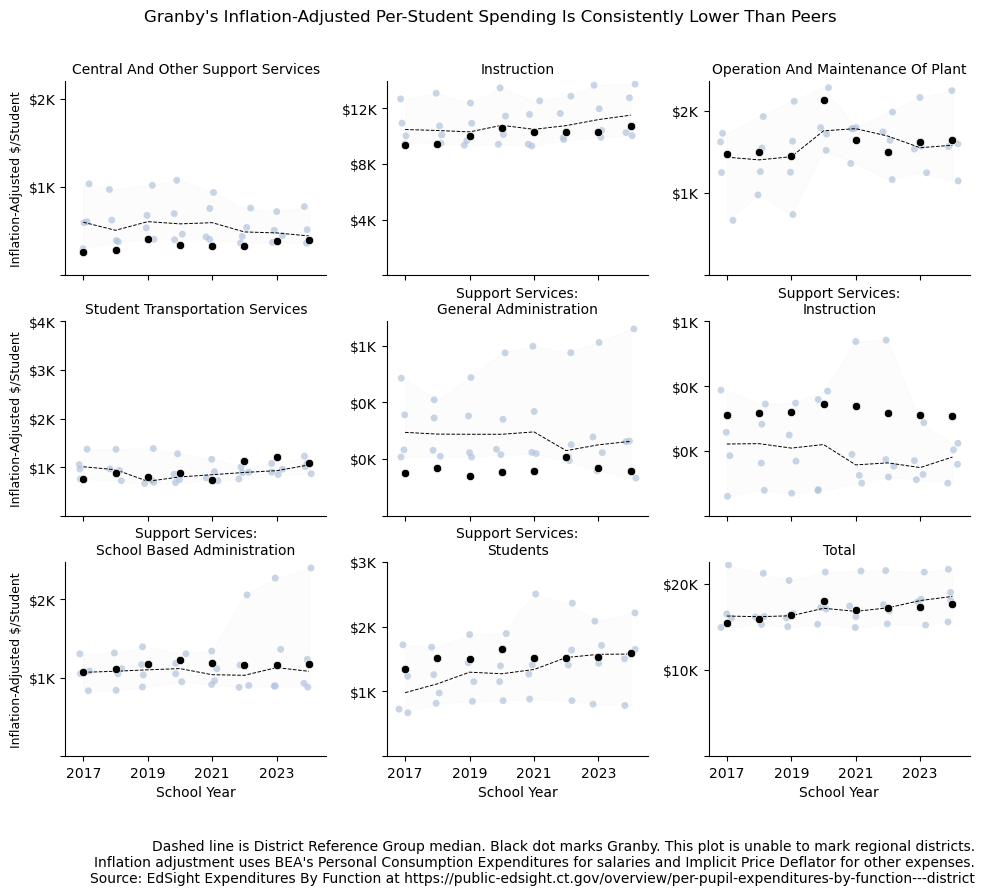

In [26]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay

_df = data=peer_expenditures[~(peer_expenditures['Function'].str.startswith('Adminis'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE']].copy()
# need a granby series
_df['Granby Real PPE'] = _df['Real PPE'].where(_df['Town'] == 'Granby', None)
_df['Real PPE'] = _df['Real PPE'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=3, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPE', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Inflation-Adjusted $/Student", fontsize=9)
doit=0

for ax in g.axes.flat:
    
    # Get the current title text
    # Apply the function and set the new title
    current_title = ax.get_title()
    ax.set_title(split_function(current_title), fontsize=10, y=1)

    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.set_ylim(bottom=1)
    
    if ax.get_title().startswith('Student Transp'):
        ax.set_ylim(top=4000)

    if ax.get_title().startswith('Central And O'):
        ax.set_ylim(top=2200)
        
    # thin ticks
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 5) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)


plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.15)

g.fig.suptitle("Granby's Inflation-Adjusted Per-Student Spending Is Consistently Lower Than Peers")

line1 = "Dashed line is District Reference Group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/ppe_spending_facet_real.png", dpi=200, metadata=png_metadata)

plt.show()